# Watt's the Cost — Exploratory Data Analysis
#### Julia Craciun
---
Now that the data has been cleaned and consolidated, we explore its structure, distributions, and relationships before modelling.

In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np
import pgeocode
import plotly.express as px

# Prevent matplotlib from interpreting $ signs as LaTeX
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False

sns.set_theme(style='whitegrid', palette='muted')

def clean_label(s):
    """Strip characters that trigger matplotlib's math parser."""
    return s.replace('$', '').replace('_', ' ')

## 1. Load Data

Below, we read in the dataset and output the number of rows and columns. 

In [2]:
df = pd.read_parquet(r'data/cleaned_data.parquet', engine='pyarrow')
print(f'Shape: {df.shape}')
df.head()


Shape: (166987, 106)


,zip,households,moe_households,households_less_than_$10k,moe_households_less_than_$10k,households_$10k_to_$14k,moe_households_$10k_to_$14k,households_$15k_to_$24k,moe_households_$15k_to_$24k,households_$25k_to_$34k,...,Utility Wind_Pct,Utility Wood and Wood Waste_Pct,Utility Total_Generation_MWh,Utility Res Sales MWh,Utility Com Sales MWh,Utility Ind Sales MWh,service_type,ownership,rate_type_index,rate
0,1002,9715,427,9.7,3.2,5.5,2.0,9.2,3.6,5.9,...,0.0,0.0,2062.0,4335004,7312220,2274974,Delivery,Investor Owned,2,0.142767
1,1005,1688,185,1.0,1.6,4.4,5.6,4.1,5.3,4.0,...,0.0,0.0,2062.0,4335004,7312220,2274974,Delivery,Investor Owned,2,0.142767
2,1007,6429,359,2.7,1.5,2.9,1.6,6.2,3.1,4.6,...,0.0,0.0,2062.0,4335004,7312220,2274974,Delivery,Investor Owned,2,0.142767
3,1009,367,151,10.6,12.7,4.6,7.8,14.2,21.2,9.5,...,0.0,0.0,2062.0,4335004,7312220,2274974,Delivery,Investor Owned,2,0.142767
4,1010,1479,110,2.6,2.2,3.9,4.4,5.8,3.4,5.3,...,0.0,0.0,2062.0,4335004,7312220,2274974,Delivery,Investor Owned,2,0.142767


## 2. Dataset Overview

### 2.1 Schema and Data Types

The dataset is the result of joining several sources on ZIP code. The updated cleaning
notebook added four new **INNER JOINs** on top of the original pipeline (race, regional
source mix, per-utility generation mix, utility sales) — rows marked *(new)* below.
Because these are inner joins, any ZIP/utility row without a match in *all* of the new
tables is dropped from the dataset.

| Feature Group | Columns | Description |
|---|---|---|
| **Identifier** | `zip` | US ZIP code (stored as int64 — leading zeros lost for New England ZIPs) |
| **Income** | `households`, `households_*`, `moe_*` | ACS S1901: total households, % in each income bracket, median/mean income, margins of error |
| **Race** *(new)* | `total_population`, `white_alone`, `black_or_african_american_alone`, etc. | ACS B02001: total population and breakdown by race, with margins of error |
| **Business** | `est`, `n<5` … `n1000` | ZBP 2023: establishment count and counts by employee size class |
| **Regional Source Mix** *(new)* | `Regional * Pct`, `Non-Base Regional * Pct` | eGRID 2023: % of the ZIP's regional grid subregion generation coming from each fuel source (coal, gas, nuclear, hydro, wind, solar, etc.) |
| **Power Plant Generation Mix** *(new)* | `Utility *_Pct`, `Utility Total_Generation_MWh` | EIA-923: % of the *specific utility's own* generation coming from each fuel type, plus total MWh generated |
| **Utility Sales** *(new)* | `Utility Res Sales MWh`, `Utility Com Sales MWh`, `Utility Ind Sales MWh` | EIA-861: utility-level electricity sales volume by customer class (loaded as text — cast to numeric in Section 14) |
| **Utility** | `service_type`, `ownership` | OpenEI: whether the utility is Bundled/Delivery/Energy and its ownership type |
| **Target** | `rate` | Electricity rate in $/kWh |
| **Rate type** | `rate_type_index` | 0 = commercial, 1 = industrial, 2 = residential |


In [3]:
print(df.dtypes)
print(f'\nTotal rows: {len(df):,}')
print(f'Unique ZIPs: {df["zip"].nunique():,}')

zip                                int64
households                         int64
moe_households                     int64
households_less_than_$10k        float64
moe_households_less_than_$10k    float64
                                  ...   
Utility Ind Sales MWh                str
service_type                         str
ownership                            str
rate_type_index                    int32
rate                             float64
Length: 106, dtype: object

Total rows: 166,987
Unique ZIPs: 19,322


### 2.2 Missing Values

We verify that there are no `NaNs` left in the dataset before we proceed. 

In [4]:
df.isnull().any().sum()

0

### 2.3 ZIP Code Uniqueness

ZIP codes are not unique — each ZIP can appear multiple times because:
1. Multiple utility providers may serve the same ZIP
2. Each utility files separate rates for residential (2), industrial (1), and commercial (0) customers

This means the income and business features are repeated across rows that share a ZIP.

In [5]:
print(f'Unique ZIPs: {df["zip"].nunique():,}')
print(f'Total rows:  {len(df):,}')
print(f'Avg rows per ZIP: {len(df)/df["zip"].nunique():.1f}')

print('\nRows per ZIP (top 10 counts):')
print(df.groupby('zip').size().value_counts().head(10))

print('\nZIPs with most rows:')
print(df['zip'].value_counts().head(5))

Unique ZIPs: 19,322
Total rows:  166,987
Avg rows per ZIP: 8.6

Rows per ZIP (top 10 counts):
3     6466
12    3684
6     2804
9     1597
10    1459
15    1146
13     571
21     336
24     308
16     156
Name: count, dtype: int64

ZIPs with most rows:
zip
10524    48
97028    45
97041    45
97049    45
97112    45
Name: count, dtype: int64


We take the most popular zip code as an example to see exactly how much each of the rows differ. 

In [6]:
top_zip = df['zip'].value_counts().index[0]
filtered = df[df['zip'] == top_zip]
print(f'ZIP {top_zip} — unique values per column:')
for col in filtered.columns:
    print(f'  {col}: {filtered[col].unique()}')

ZIP 10524 — unique values per column:
  zip: [10524]
  households: [1613]
  moe_households: [163]
  households_less_than_$10k: [2.1]
  moe_households_less_than_$10k: [2.2]
  households_$10k_to_$14k: [0.7]
  moe_households_$10k_to_$14k: [1.1]
  households_$15k_to_$24k: [3.]
  moe_households_$15k_to_$24k: [2.3]
  households_$25k_to_$34k: [4.6]
  moe_households_$25k_to_$34k: [3.8]
  households_$35k_to_$49k: [2.7]
  moe_households_$35k_to_$49k: [2.5]
  households_$50k_to_$74k: [16.1]
  moe_households_$50k_to_$74k: [5.9]
  households_$75k_to_$99k: [7.9]
  moe_households_$75k_to_$99k: [3.9]
  households_$100k_to_$149k: [19.5]
  moe_households_$100k_to_$149k: [6.]
  households_$150k_to_$199k: [16.3]
  moe_households_$150k_to_$199k: [5.]
  households_$200k_or_more: [27.1]
  moe_households_$200k_or_more: [5.6]
  households_median_income: [125568.]
  moe_households_median_income: [24847.]
  households_mean_income: [164852.]
  moe_households_mean_income: [14126.]
  households_percent_allocated_ho

Above, we see that there are instances where multiple of the same features map to different rates. This might inflate errors and reduce predictive power. As a result, we will likely aggregate rows that same the share features, but different outcomes before the modeling process. 

### 2.4 New Columns Introduced by the Updated Cleaning Pipeline

We programmatically flag which columns are new (i.e. not part of the previously
documented schema above) and bucket them by source, so it's clear exactly what changed
without hand-typing column names that may shift if the upstream source files change.


In [7]:
# Columns that existed in the dataset before the teammate's update
old_known_cols = {
    'zip',
    # business
    'est', 'n<5', 'n5_9', 'n10_19', 'n20_49', 'n50_99', 'n100_249', 'n250_499', 'n500_999', 'n1000',
    # utility / target
    'service_type', 'ownership', 'rate', 'rate_type_index',
}
# Income columns (brackets + margins of error) also predate this update
old_known_cols |= {c for c in df.columns if c.startswith('households') or c.startswith('moe_')}

new_cols = [c for c in df.columns if c not in old_known_cols]

SALES_COLS = {'Utility Res Sales MWh', 'Utility Com Sales MWh', 'Utility Ind Sales MWh'}


def bucket_new_column(col):
    if col in SALES_COLS:
        return 'Utility Sales'
    if col.startswith('Utility ') and (col.endswith('_Pct') or col == 'Utility Total_Generation_MWh'):
        return 'Power Plant Generation Mix'
    if 'Regional' in col or 'Non-Base' in col:
        return 'Regional Source Mix'
    return 'Race'


new_col_groups = {}
for col in new_cols:
    new_col_groups.setdefault(bucket_new_column(col), []).append(col)

for group, cols in new_col_groups.items():
    print(f'{group} ({len(cols)} columns):')
    for c in cols:
        print(f'  - {c}')
    print()

print(f'Total new columns: {len(new_cols)} / {len(df.columns)}')


Race (10 columns):
  - total_population
  - white_alone
  - black_or_african_american_alone
  - american_indian_and_alaska_native_alone
  - asian_alone
  - native_hawaiian_and_other_pacific_islander_alone
  - some_other_race_alone
  - two_or_more_races:
  - two_or_more_races:_two_races_including_some_other_race
  - two_or_more_races:_two_races_excluding_some_other_race,_and_three_or_more_races

Regional Source Mix (22 columns):
  - Regional Coal Pct
  - Regional Oil Pct
  - Regional Gas Pct
  - Regional Nuclear Pct
  - Regional Hydroelectric Pct
  - Regional Biomass Pct
  - Regional Wind Pct
  - Regional Solar Pct
  - Regional Geothermal Pct
  - Regional Other Fossil Pct
  - Regional Other Unknown Pct
  - Non-Base Regional Coal Pct
  - Non-Base Regional Oil Pct
  - Non-Base Regional Gas Pct
  - Non-Base Regional Nuclear Pct
  - Non-Base Regional Hydroelectric Pct
  - Non-Base Regional Biomass Pct
  - Non-Base Regional Wind Pct
  - Non-Base Regional Solar Pct
  - Non-Base Regional Geoth

## 3. Target Variable: `rate`

The target is `rate` ($/kWh), with `rate_type_index` indicating whether it is a residential (2), commercial (0), or industrial (1) rate. Zero values were removed during cleaning as they represent missing or inapplicable rates.

In [8]:
print(df[['rate']].describe())

                rate
count  166987.000000
mean        0.114548
std         0.073401
min         0.001273
25%         0.071225
50%         0.101762
75%         0.139159
max         0.644231


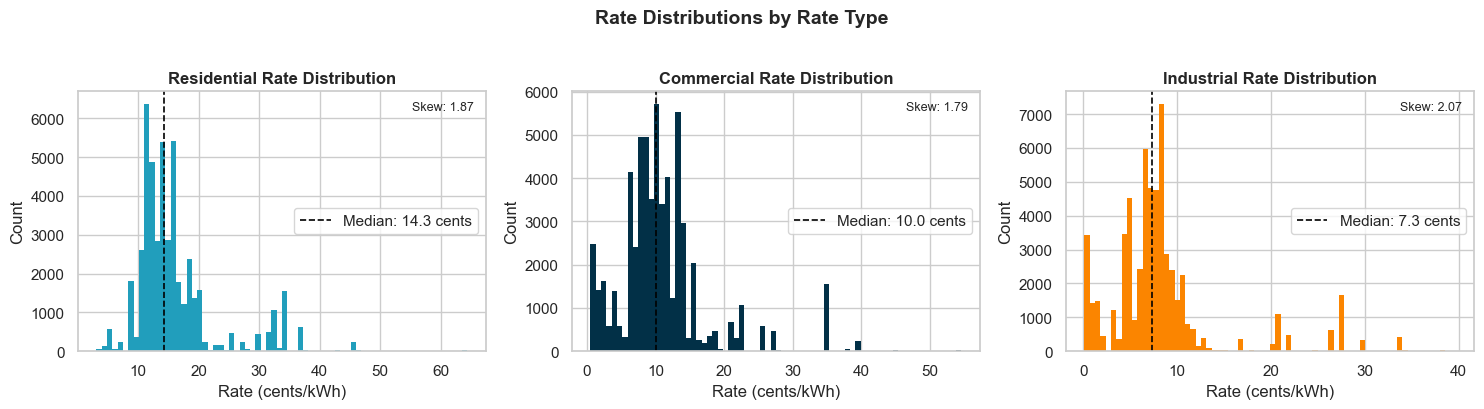

In [9]:
# Rate distribution split by rate_type_index
rate_labels = {0: 'Commercial', 1: 'Industrial', 2: 'Residential'}
colors = {0: '#023047', 1: '#fb8500', 2: '#219ebc'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    data = df[df['rate_type_index'] == idx]['rate'] * 100
    ax.hist(data, bins=70, color=colors[idx], edgecolor='none')
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median: {data.median():.1f} cents')
    ax.set_title(f'{rate_labels[idx]} Rate Distribution', fontweight='bold')
    ax.set_xlabel('Rate (cents/kWh)')
    ax.set_ylabel('Count')
    ax.text(0.97, 0.93, f'Skew: {data.skew():.2f}', transform=ax.transAxes,
            ha='right', fontsize=9)
    ax.legend()

plt.suptitle('Rate Distributions by Rate Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
df[['zip', 'rate', 'rate_type_index', 'ownership', 'service_type']].sort_values('rate', ascending=False)[0:20]


,zip,rate,rate_type_index,ownership,service_type
148632,99559,0.644231,2,Cooperative,Bundled
152909,99760,0.644231,2,Cooperative,Bundled
148701,99765,0.644231,2,Cooperative,Bundled
148702,99770,0.644231,2,Cooperative,Bundled
148703,99771,0.644231,2,Cooperative,Bundled
148704,99772,0.644231,2,Cooperative,Bundled
148641,99585,0.644231,2,Cooperative,Bundled
148706,99778,0.644231,2,Cooperative,Bundled
148659,99650,0.644231,2,Cooperative,Bundled
148708,99783,0.644231,2,Cooperative,Bundled


All three of the distributions are right-skewed. Residential rates are highest (median ~14 cents), commercial lower (~12 cents), and industrial lowest (~8 cents). It appears that the highest rates are associated with Alaskan zip codes. 

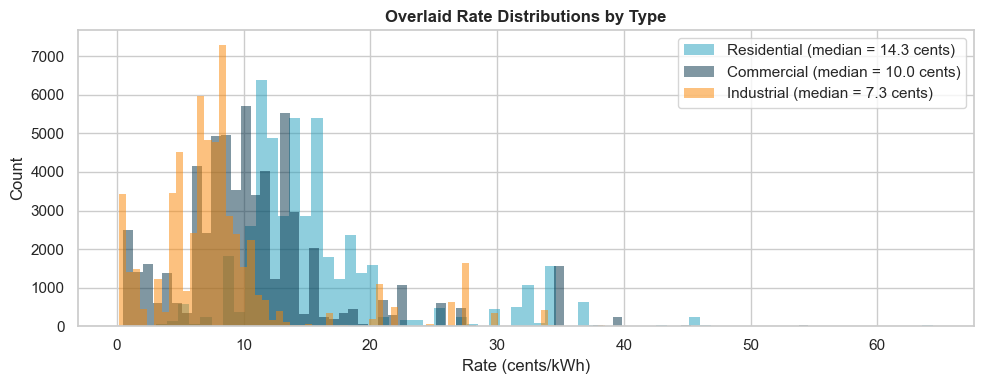

In [11]:
# overlaid density for direct comparison
fig, ax = plt.subplots(figsize=(10, 4))
for idx in [2, 0, 1]:
    data = df[df['rate_type_index'] == idx]['rate'] * 100
    ax.hist(data, bins=70, alpha=0.5, color=colors[idx],
            label=f'{rate_labels[idx]} (median = {data.median():.1f} cents)', edgecolor='none')

ax.set_xlabel('Rate (cents/kWh)')
ax.set_ylabel('Count')
ax.set_title('Overlaid Rate Distributions by Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Categorical Features

### 4.1 Service Type

- **Bundled**: utility handles generation, transmission, and delivery — the rate is all-in
- **Delivery**: deregulated markets where the utility only charges for the wire; supply is billed separately
- **Energy**: supply-only charge with no delivery component (7 rows — negligible)

For predicting what a customer actually pays, Bundled is the most meaningful service type.

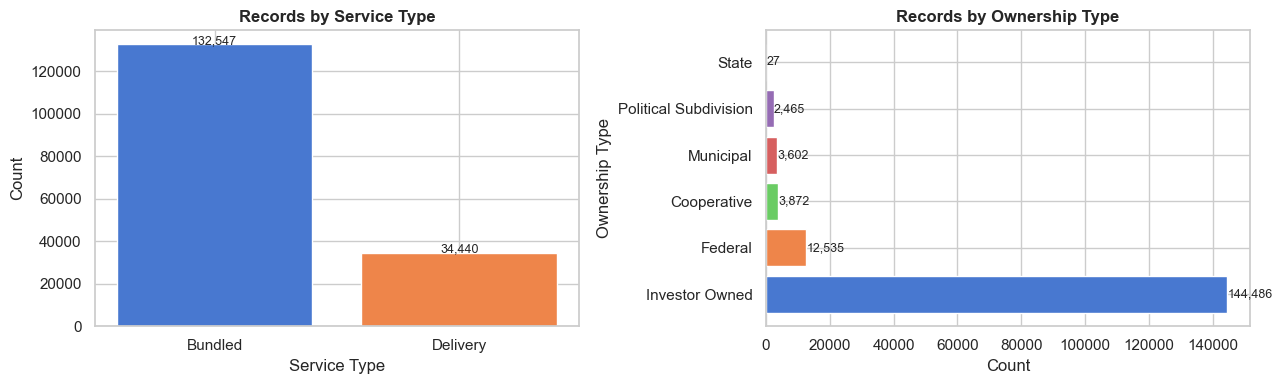

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

svc = df['service_type'].value_counts()
axes[0].bar(svc.index, svc.values, color=sns.color_palette('muted', len(svc)))
axes[0].set_title('Records by Service Type', fontweight='bold')
axes[0].set_xlabel('Service Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(svc.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

own = df['ownership'].value_counts()
axes[1].barh(own.index, own.values, color=sns.color_palette('muted', len(own)))
axes[1].set_title('Records by Ownership Type', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Ownership Type')
for i, v in enumerate(own.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

It appears that most overnship is Investor Owned, followed by Cooperative ownership. 

### 4.2 Rate by Ownership Type

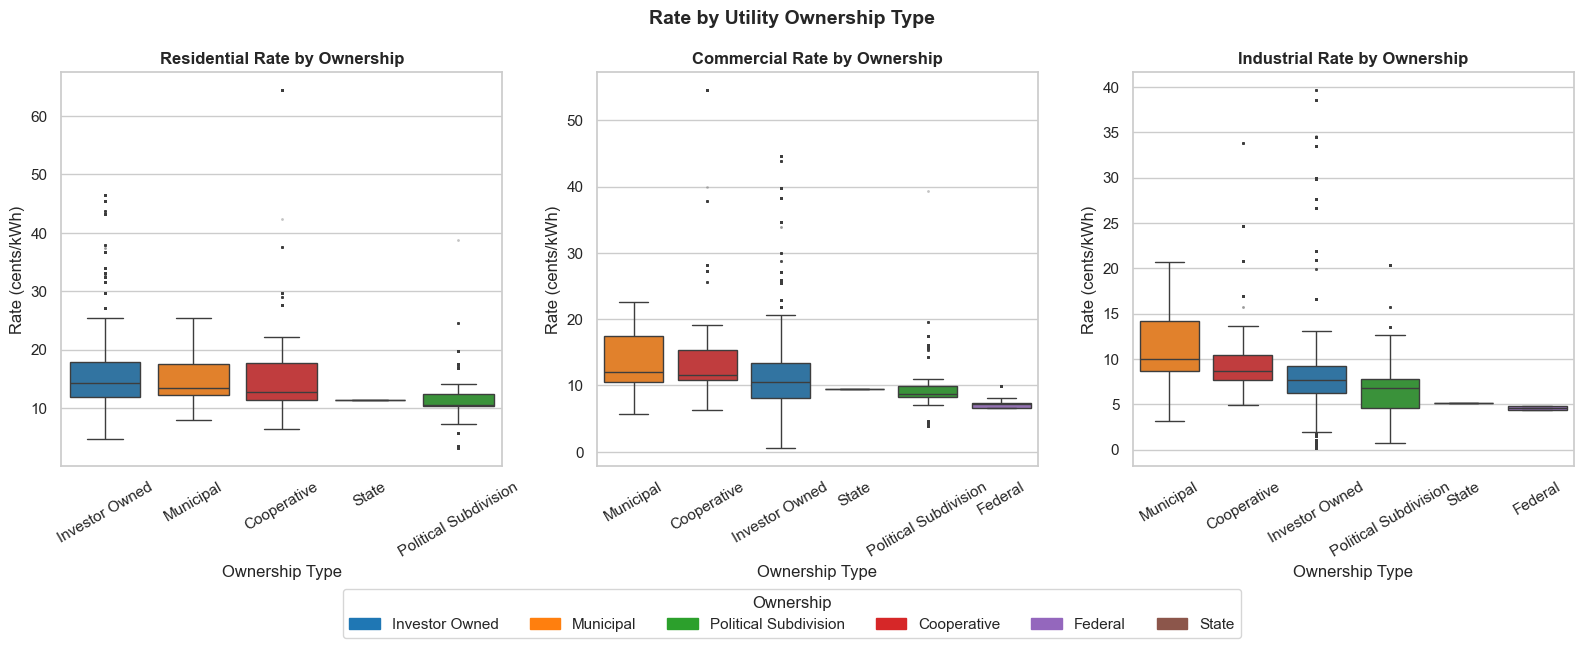

In [13]:
ownership_categories = df['ownership'].unique().tolist()
palette = dict(zip(ownership_categories, sns.color_palette('tab10', len(ownership_categories))))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for idx, ax in zip([2, 0, 1], axes):
    data = df[df['rate_type_index'] == idx][['ownership', 'rate']].copy()
    data['rate'] = data['rate'] * 100
    order = data.groupby('ownership')['rate'].median().sort_values(ascending=False).index.tolist()

    sns.boxplot(data=data, x='ownership', y='rate', order=order, ax=ax,
                hue='ownership', hue_order=order, palette=palette, legend=False,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

    ax.set_title(f'{rate_labels[idx]} Rate by Ownership', fontweight='bold')
    ax.set_xlabel('Ownership Type')  # explicit label on all three
    ax.set_ylabel('Rate (cents/kWh)')
    ax.tick_params(axis='x', rotation=30)


handles = [plt.Rectangle((0,0),1,1, color=palette[o]) for o in ownership_categories]
fig.legend(handles, ownership_categories, title='Ownership',
           loc='lower center', ncol=len(ownership_categories), bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Rate by Utility Ownership Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Income Features

### 5.1 Income Bracket Distribution

Note: the `households_$X_to_$Y` columns represent **percentages** of households in each bracket, not raw counts.

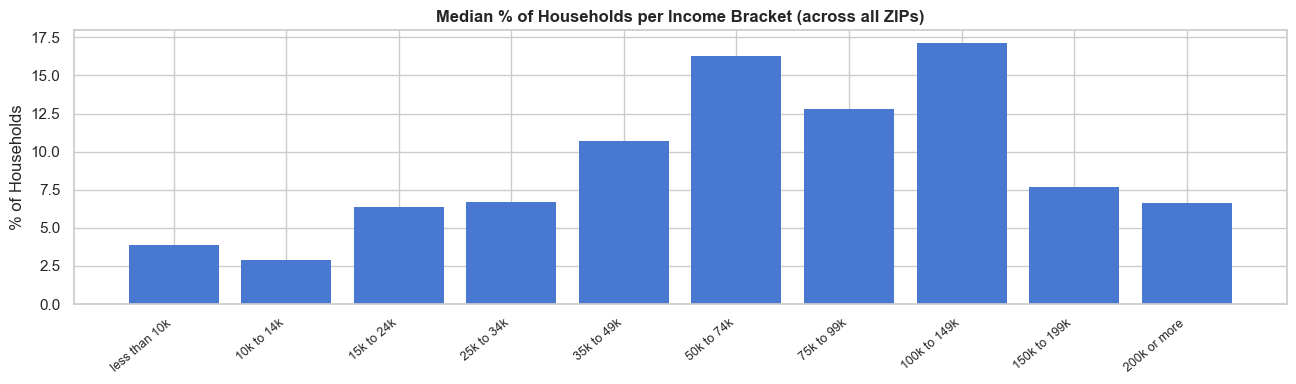

In [14]:
income_cols = [c for c in df.columns if
               (c.startswith('households_') and 'moe' not in c
                and c not in ['households','households_median_income',
                              'households_mean_income',
                              'households_percent_allocated_household_income_in_the_past_12_months'])]

medians = df[income_cols].median()
clean_labels = [clean_label(c).replace('households ','') for c in medians.index]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(medians)), medians.values, color='#4878CF', edgecolor='none')
ax.set_xticks(range(len(medians)))
ax.set_xticklabels(clean_labels, rotation=40, ha='right', fontsize=9)
ax.set_title('Median % of Households per Income Bracket (across all ZIPs)', fontweight='bold')
ax.set_ylabel('% of Households')
plt.tight_layout()
plt.show()

There appears to be one cluster around 50k-74k and another around 100k-149k. Low-income brackets (<25k) are small, reflecting that ZIPs tend to be middle-income on average.

### 5.2 Median Income vs Rate

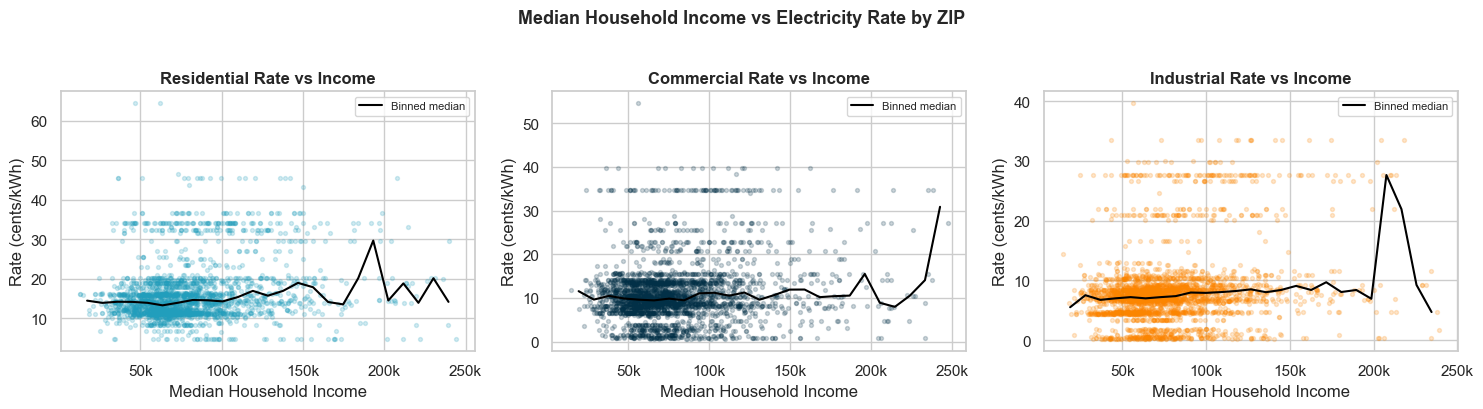

In [15]:
sample = df.sample(min(8000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    ax.scatter(s['households_median_income'], s['rate'] * 100,
               alpha=0.2, s=8, color=colors[idx])
    # Binned trend
    s = s.copy()
    s['bin'] = pd.cut(s['households_median_income'], bins=25)
    trend = s.groupby('bin')['rate'].median() * 100
    centers = [iv.mid for iv in trend.index]
    ax.plot(centers, trend.values, color='black', linewidth=1.5, label='Binned median')
    ax.set_xlabel('Median Household Income')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Income', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend(fontsize=8)

plt.suptitle('Median Household Income vs Electricity Rate by ZIP', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Income alone is a weak predictor, since there is high variance at every income level.

## 6. Business Features

### 6.1 Establishment Size Class Distribution

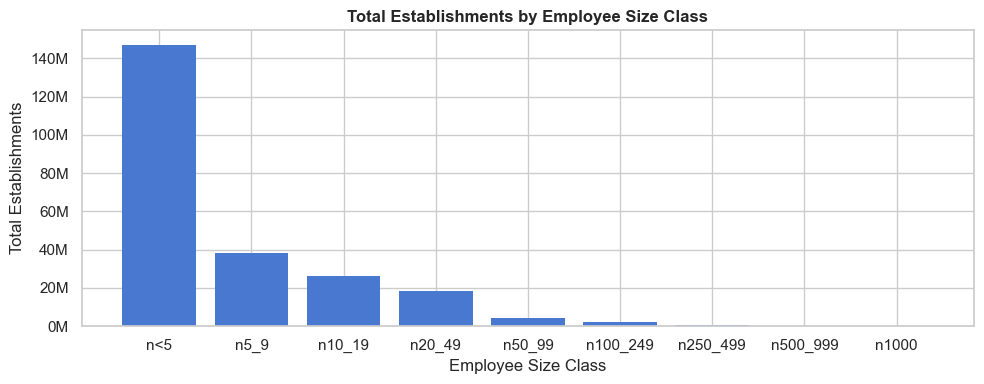

In [16]:
size_cols = ['n<5','n5_9','n10_19','n20_49','n50_99','n100_249','n250_499','n500_999','n1000']
available = [c for c in size_cols if c in df.columns]

totals = df[available].sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(totals.index, totals.values, color='#4878CF', edgecolor='none')
ax.set_title('Total Establishments by Employee Size Class', fontweight='bold')
ax.set_xlabel('Employee Size Class')
ax.set_ylabel('Total Establishments')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

The vast majority of US businesses have fewer than 5 employees. The distribution drops off sharply, meaning the n<5 column will likely dominate any business-feature signal. Therefore, a log-transform might  help during modelling.

### 6.2 Business Density vs Rate

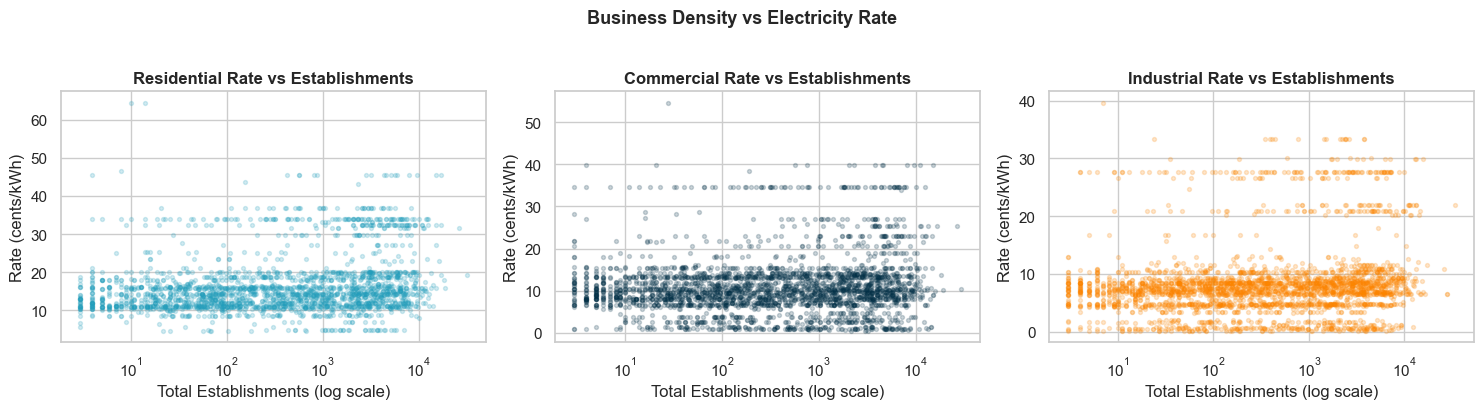

In [17]:
sample = df.sample(min(8000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    ax.scatter(s['est'], s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
    ax.set_xscale('log')
    ax.set_xlabel('Total Establishments (log scale)')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Establishments', fontweight='bold')

plt.suptitle('Business Density vs Electricity Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Data Quality: Margin of Error Analysis

The ACS income columns come with margins of error (MOE). A high MOE-to-value ratio means that estimate is statistically unreliable for that ZIP.

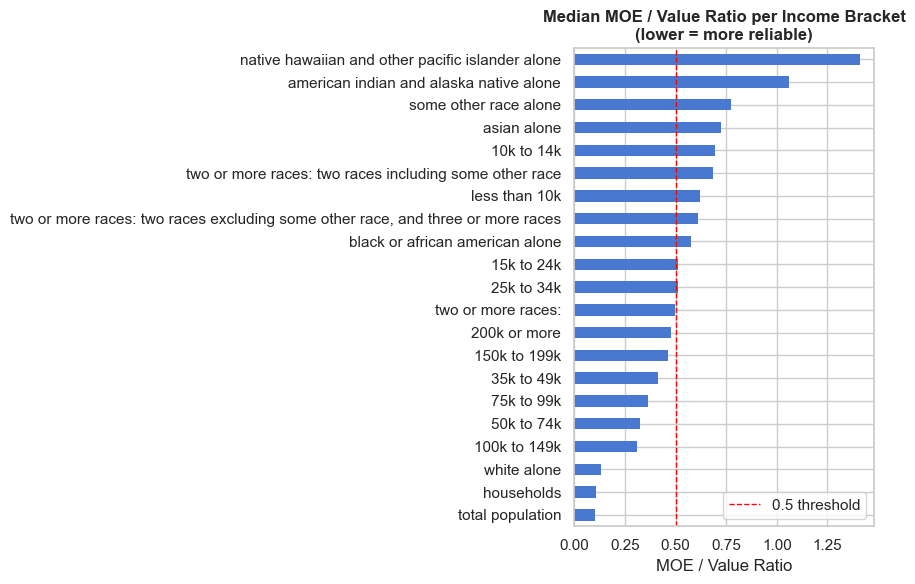

In [18]:
moe_cols = [c for c in df.columns if c.startswith('moe_') and 'income' not in c]
val_cols = [c.replace('moe_', '') for c in moe_cols]

ratios = {}
for moe, val in zip(moe_cols, val_cols):
    if val in df.columns:
        ratio = (df[moe] / df[val].replace(0, float('nan'))).median()
        ratios[clean_label(val).replace('households ','')] = ratio

fig, ax = plt.subplots(figsize=(9, 6))
pd.Series(ratios).sort_values().plot.barh(ax=ax, color='#4878CF', edgecolor='none')
ax.set_title('Median MOE / Value Ratio per Income Bracket\n(lower = more reliable)', fontweight='bold')
ax.set_xlabel('MOE / Value Ratio')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='0.5 threshold')
ax.legend()
plt.tight_layout()
plt.show()

Brackets with ratios above 0.5 have margins of error more than half their estimated value. Very low-income brackets appear to be less reliable, potentially due to a smaller sample.  

## 8. Correlation Analysis

### 8.1 Feature Correlations with Rate

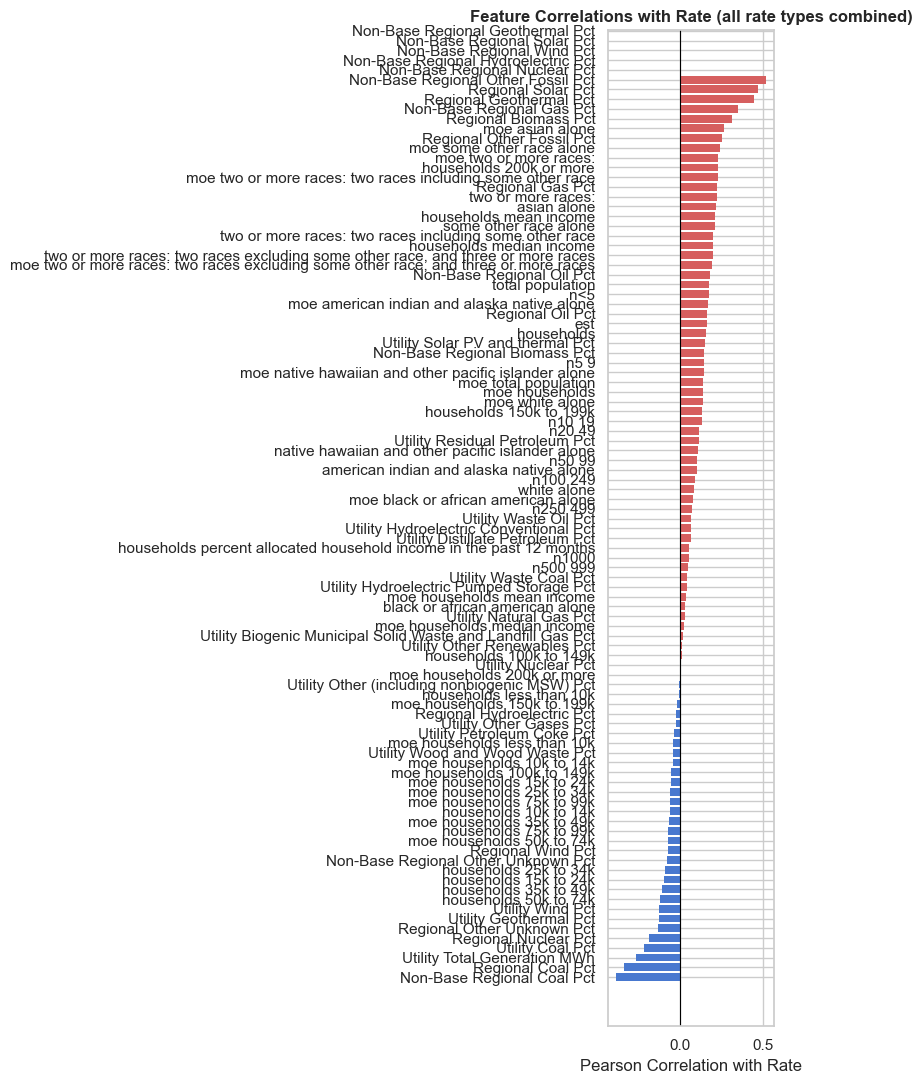

In [19]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude = ['zip', 'rate', 'rate_type_index']
numeric_cols = [c for c in numeric_cols if c not in exclude]

corrs = df[numeric_cols + ['rate']].corr()['rate'].drop('rate').sort_values()
clean_idx = [clean_label(c) for c in corrs.index]

fig, ax = plt.subplots(figsize=(8, 11))
bar_colors = ['#D65F5F' if v > 0 else '#4878CF' for v in corrs.values]
ax.barh(clean_idx, corrs.values, color=bar_colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Rate')
ax.set_title('Feature Correlations with Rate (all rate types combined)', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Feature Heatmap (Top Correlators)

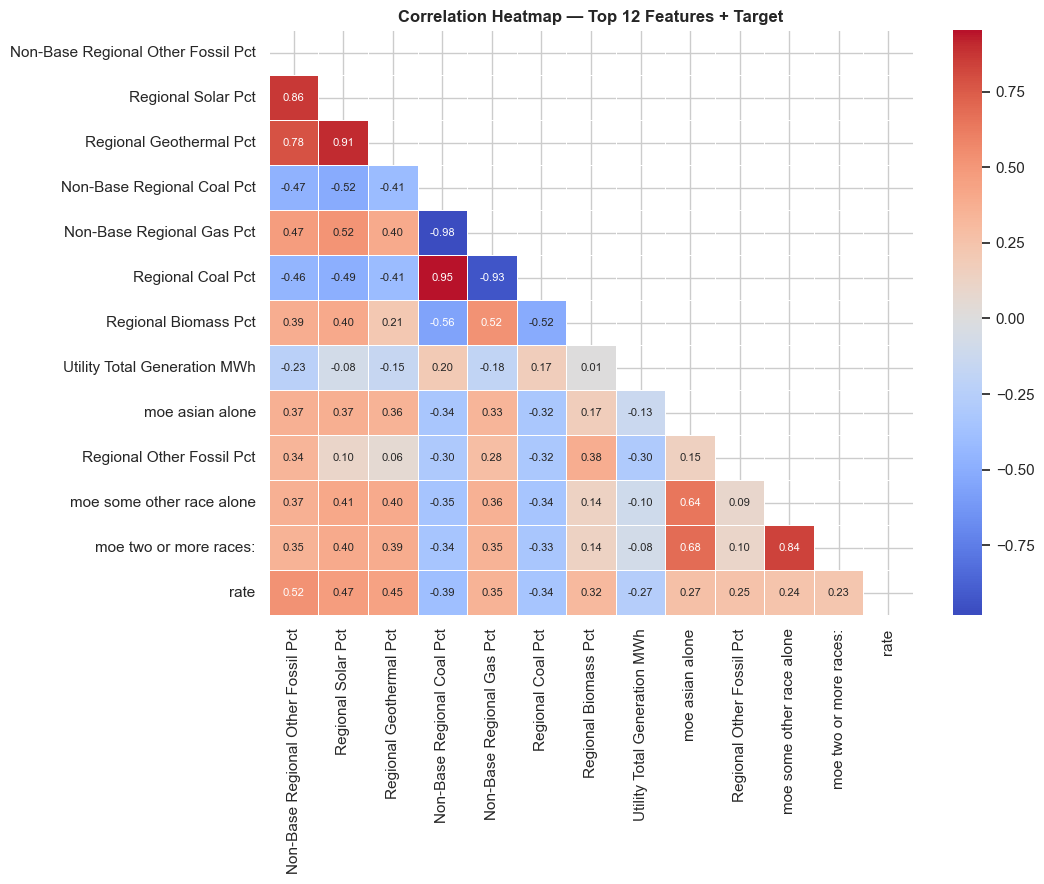

In [20]:
top_feats = corrs.abs().sort_values(ascending=False).head(12).index.tolist()
heatmap_df = df[top_feats + ['rate']].corr()
heatmap_df.columns = [clean_label(c) for c in heatmap_df.columns]
heatmap_df.index = heatmap_df.columns

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(heatmap_df, dtype=bool))
sns.heatmap(heatmap_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 12 Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Geographic Distribution

### 9.1 ZIP Coverage by State

In [21]:
nomi = pgeocode.Nominatim('us')
zip_list = df['zip'].astype(str).str.zfill(5).unique().tolist()
geo = nomi.query_postal_code(zip_list)[['postal_code','state_code']].dropna()
state_counts = geo.groupby('state_code').size().reset_index(name='zip_count')

fig = px.choropleth(state_counts, locations='state_code', locationmode='USA-states',
                    color='zip_count', scope='usa', color_continuous_scale='Blues',
                    title='Number of ZIP Codes Covered per State')
fig.update_layout(margin={'r':0,'t':30,'l':0,'b':0})
fig.show()

### 9.2 Median Residential Rate by State

In [22]:
geo_df = geo.copy()
geo_df.columns = ['zip_str', 'state_code']
df['zip_str'] = df['zip'].astype(str).str.zfill(5)

res_df = df[df['rate_type_index'] == 2].copy()
merged = res_df.merge(geo_df, left_on='zip_str', right_on='zip_str')
state_rates = merged.groupby('state_code')['rate'].median().reset_index()
state_rates['rate_cents'] = state_rates['rate'] * 100

fig = px.choropleth(state_rates, locations='state_code', locationmode='USA-states',
                    color='rate_cents', scope='usa', color_continuous_scale='RdYlGn_r',
                    title='Median Residential Electricity Rate by State (cents/kWh)',
                    labels={'rate_cents': 'cents/kWh'})
fig.update_layout(margin={'r':0,'t':30,'l':0,'b':0})
fig.show()

California, Hawaii, and Alaska have the highest rates. The Southeast and Northwest tend to have lower rates.

## 10. Census Imputation Flag

`households_percent_allocated_household_income_in_the_past_12_months` measures what % of households had their income statistically imputed rather than reported. High values indicate lower data quality for that ZIP.

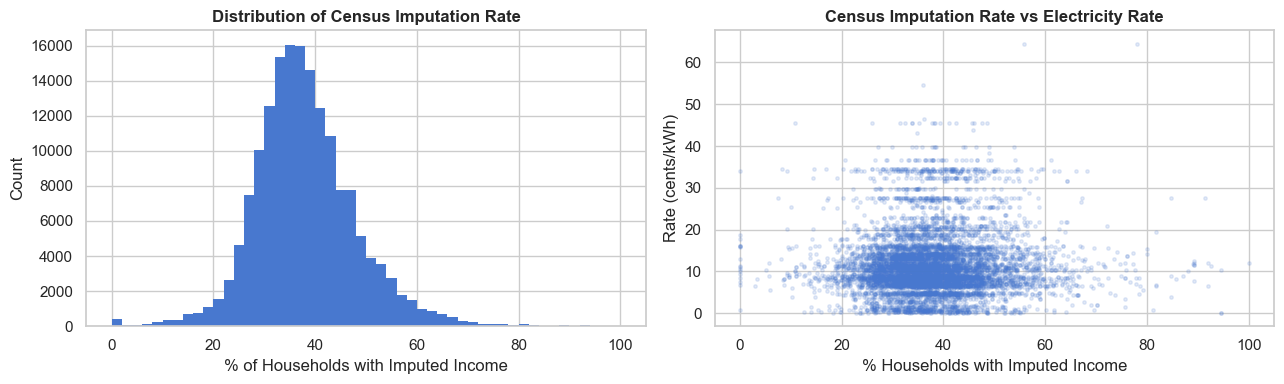

In [23]:
col = 'households_percent_allocated_household_income_in_the_past_12_months'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[col].hist(bins=50, ax=axes[0], color='#4878CF', edgecolor='none')
axes[0].set_title('Distribution of Census Imputation Rate', fontweight='bold')
axes[0].set_xlabel('% of Households with Imputed Income')
axes[0].set_ylabel('Count')

sample = df.sample(min(8000, len(df)), random_state=42)
axes[1].scatter(sample[col], sample['rate'] * 100, alpha=0.15, s=6, color='#4878CF')
axes[1].set_xlabel('% Households with Imputed Income')
axes[1].set_ylabel('Rate (cents/kWh)')
axes[1].set_title('Census Imputation Rate vs Electricity Rate', fontweight='bold')

plt.tight_layout()
plt.show()

No strong relationship with rate is visible, suggesting data quality (as measured by imputation) is not systematically biased toward high- or low-rate areas.

## 11. Race Demographics

The updated pipeline joins ACS B02001 racial population data by ZIP. We look at the
composition across ZIPs and whether any category relates to electricity rate. Note this
reflects ZIP-level demographics correlated with *which utility happens to serve that
ZIP*, not a causal driver of rates — treat as descriptive.


In [24]:
race_cols = new_col_groups.get('Race', [])
race_numeric = df[race_cols].select_dtypes(include=np.number).columns.tolist()
print(f'Detected {len(race_numeric)} numeric race-related columns:')
print(race_numeric)


Detected 10 numeric race-related columns:
['total_population', 'white_alone', 'black_or_african_american_alone', 'american_indian_and_alaska_native_alone', 'asian_alone', 'native_hawaiian_and_other_pacific_islander_alone', 'some_other_race_alone', 'two_or_more_races:', 'two_or_more_races:_two_races_including_some_other_race', 'two_or_more_races:_two_races_excluding_some_other_race,_and_three_or_more_races']


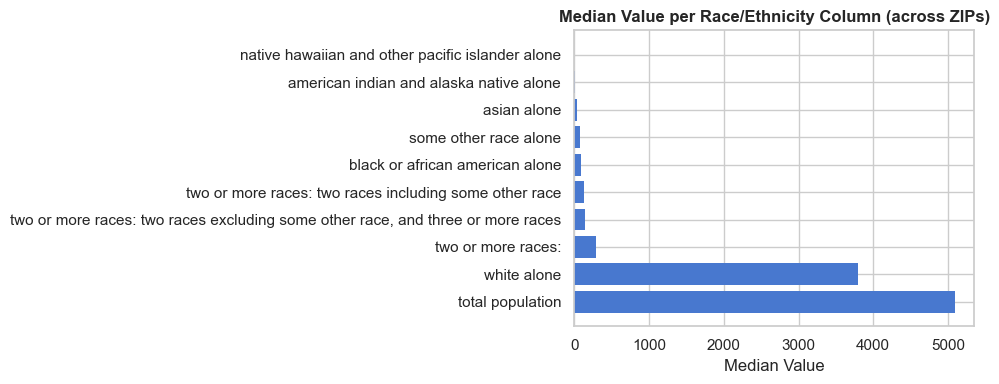

In [25]:
medians = df[race_numeric].median().sort_values(ascending=False)
clean_idx = [clean_label(c) for c in medians.index]

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(medians))))
ax.barh(clean_idx, medians.values, color='#4878CF', edgecolor='none')
ax.set_title('Median Value per Race/Ethnicity Column (across ZIPs)', fontweight='bold')
ax.set_xlabel('Median Value')
plt.tight_layout()
plt.show()


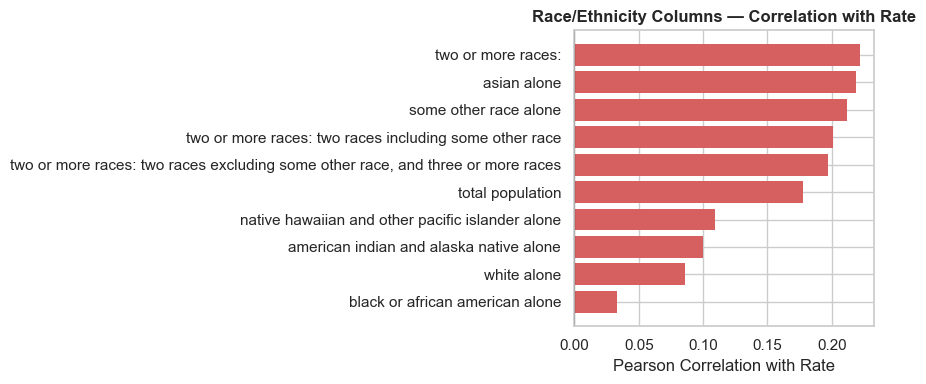

In [26]:
race_corr = df[race_numeric + ['rate']].corr()['rate'].drop('rate').sort_values()
clean_idx = [clean_label(c) for c in race_corr.index]

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(race_corr))))
bar_colors = ['#D65F5F' if v > 0 else '#4878CF' for v in race_corr.values]
ax.barh(clean_idx, race_corr.values, color=bar_colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Race/Ethnicity Columns — Correlation with Rate', fontweight='bold')
ax.set_xlabel('Pearson Correlation with Rate')
plt.tight_layout()
plt.show()


## 12. Regional Grid Source Mix

eGRID subregion generation mix (e.g. % coal, gas, nuclear, wind, solar) mapped to ZIP
via subregion. This describes the broader grid a ZIP draws power from — distinct from
the specific utility's own generation mix in Section 13.


In [27]:
region_cols = new_col_groups.get('Regional Source Mix', [])
region_pct_cols = [c for c in region_cols if df[c].dtype != 'object']
print(f'Detected {len(region_pct_cols)} regional source-mix numeric columns:')
print(region_pct_cols)


Detected 22 regional source-mix numeric columns:
['Regional Coal Pct', 'Regional Oil Pct', 'Regional Gas Pct', 'Regional Nuclear Pct', 'Regional Hydroelectric Pct', 'Regional Biomass Pct', 'Regional Wind Pct', 'Regional Solar Pct', 'Regional Geothermal Pct', 'Regional Other Fossil Pct', 'Regional Other Unknown Pct', 'Non-Base Regional Coal Pct', 'Non-Base Regional Oil Pct', 'Non-Base Regional Gas Pct', 'Non-Base Regional Nuclear Pct', 'Non-Base Regional Hydroelectric Pct', 'Non-Base Regional Biomass Pct', 'Non-Base Regional Wind Pct', 'Non-Base Regional Solar Pct', 'Non-Base Regional Geothermal Pct', 'Non-Base Regional Other Fossil Pct', 'Non-Base Regional Other Unknown Pct']


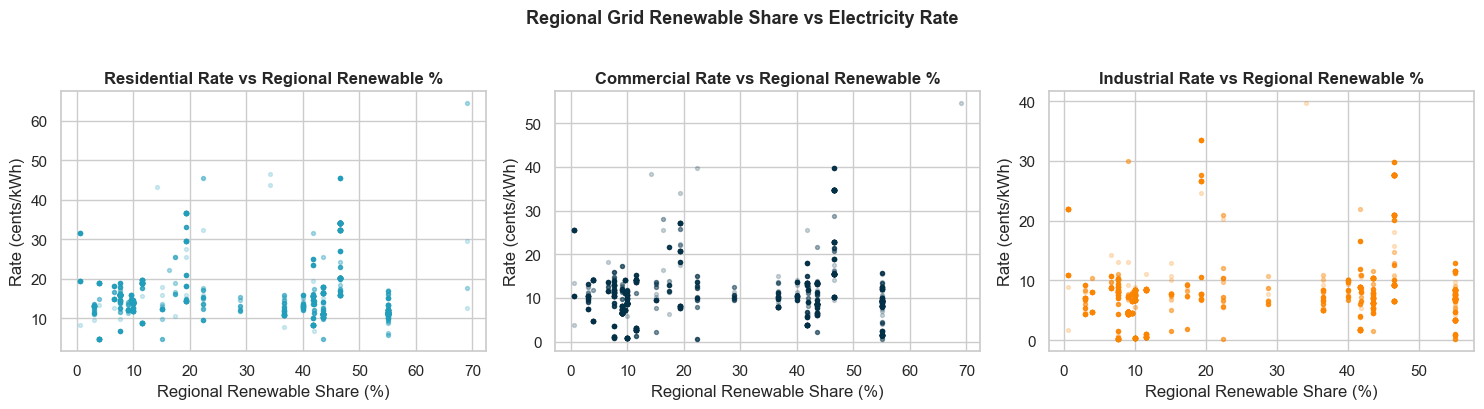

In [28]:
sample = df.sample(min(8000, len(df)), random_state=42).copy()

renewable_like = [c for c in region_pct_cols if any(k in c for k in
                  ['Wind', 'Solar', 'Hydroelectric', 'Biomass', 'Geothermal']) and 'Non-Base' not in c]

if renewable_like:
    sample['regional_renewable_pct'] = sample[renewable_like].sum(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, ax in zip([2, 0, 1], axes):
        s = sample[sample['rate_type_index'] == idx]
        ax.scatter(s['regional_renewable_pct'] * 100, s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
        ax.set_xlabel('Regional Renewable Share (%)')
        ax.set_ylabel('Rate (cents/kWh)')
        ax.set_title(f'{rate_labels[idx]} Rate vs Regional Renewable %', fontweight='bold')
    plt.suptitle('Regional Grid Renewable Share vs Electricity Rate', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No renewable-labeled regional mix columns detected — inspect `region_pct_cols` and adjust the keyword filter.')


## 13. Power Plant Generation Mix (Utility's Own Generation)

EIA-923 generation data, aggregated per operator/utility and expressed as a % of that
utility's own total generation — e.g. what fraction of *this* utility's power comes
from coal vs. wind vs. nuclear, rather than the regional grid average from Section 12.


In [29]:
gen_cols_detected = new_col_groups.get('Power Plant Generation Mix', [])
gen_pct_cols = [c for c in gen_cols_detected if c.endswith('_Pct')]
print(f'Detected {len(gen_pct_cols)} generation-mix percentage columns:')
print(gen_pct_cols)
print("'Utl Total_Generation_MWh' present:", 'Utl Total_Generation_MWh' in df.columns)


Detected 18 generation-mix percentage columns:
['Utility Biogenic Municipal Solid Waste and Landfill Gas_Pct', 'Utility Coal_Pct', 'Utility Distillate Petroleum_Pct', 'Utility Geothermal_Pct', 'Utility Hydroelectric Conventional_Pct', 'Utility Hydroelectric Pumped Storage_Pct', 'Utility Natural Gas_Pct', 'Utility Nuclear_Pct', 'Utility Other (including nonbiogenic MSW)_Pct', 'Utility Other Gases_Pct', 'Utility Other Renewables_Pct', 'Utility Petroleum Coke_Pct', 'Utility Residual Petroleum_Pct', 'Utility Solar PV and thermal_Pct', 'Utility Waste Coal_Pct', 'Utility Waste Oil_Pct', 'Utility Wind_Pct', 'Utility Wood and Wood Waste_Pct']
'Utl Total_Generation_MWh' present: False


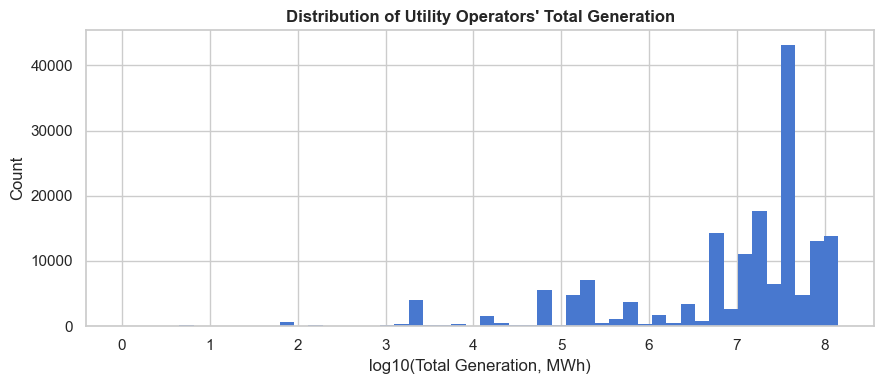

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
total_gen = df.loc[df['Utility Total_Generation_MWh'] > 0, 'Utility Total_Generation_MWh']
ax.hist(np.log10(total_gen), bins=50, color='#4878CF', edgecolor='none')
ax.set_xlabel('log10(Total Generation, MWh)')
ax.set_ylabel('Count')
ax.set_title("Distribution of Utility Operators' Total Generation", fontweight='bold')
plt.tight_layout()
plt.show()


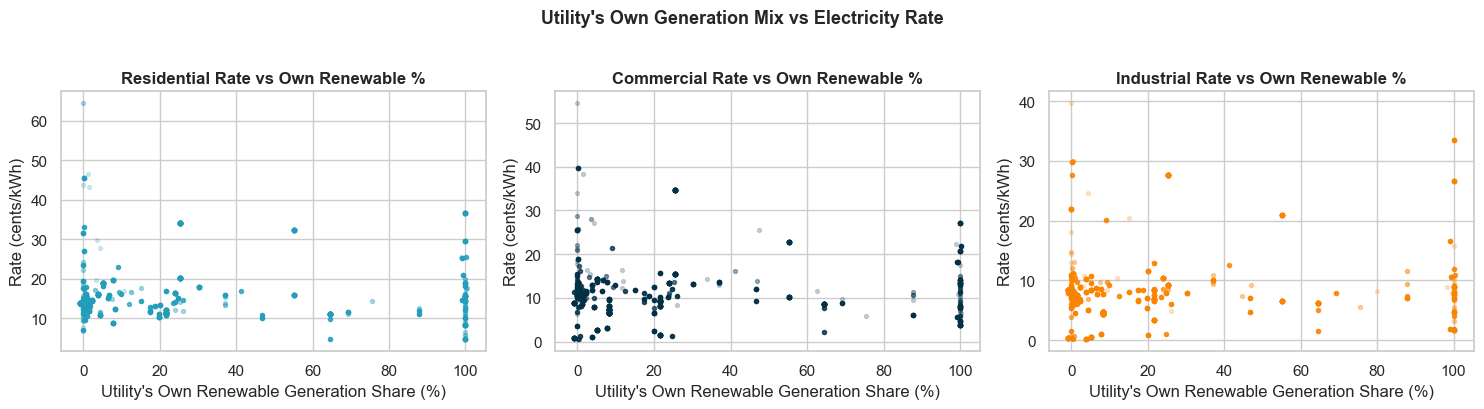

In [31]:
sample = df.sample(min(8000, len(df)), random_state=42).copy()

utl_renewable_like = [c for c in gen_pct_cols if any(k in c for k in
                      ['Solar', 'Wind', 'Hydroelectric', 'Geothermal', 'Renewables'])]

if utl_renewable_like:
    sample['utl_renewable_pct'] = sample[utl_renewable_like].sum(axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for idx, ax in zip([2, 0, 1], axes):
        s = sample[sample['rate_type_index'] == idx]
        ax.scatter(s['utl_renewable_pct'] * 100, s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
        ax.set_xlabel("Utility's Own Renewable Generation Share (%)")
        ax.set_ylabel('Rate (cents/kWh)')
        ax.set_title(f'{rate_labels[idx]} Rate vs Own Renewable %', fontweight='bold')
    plt.suptitle("Utility's Own Generation Mix vs Electricity Rate", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No renewable-labeled Utl_*_Pct columns detected — inspect `gen_pct_cols`.')


## 14. Utility Sales

EIA-861 utility-level electricity sales volume (MWh) by customer class — a proxy for
utility size / market reach, distinct from the ZIP-level business establishment counts
in Section 6.


In [32]:
sales_cols_detected = [c for c in
    ['Utility Res Sales MWh', 'Utility Com Sales MWh', 'Utility Ind Sales MWh']
    if c in df.columns]

# These loaded as text from the source file - cast to numeric
df[sales_cols_detected] = df[sales_cols_detected].apply(pd.to_numeric, errors='coerce')

df[sales_cols_detected].describe()


,Utility Res Sales MWh,Utility Com Sales MWh,Utility Ind Sales MWh
count,1.646960e+05,1.668160e+05,1.665510e+05
mean,5.838872e+06,7.026520e+06,3.729852e+06
std,8.765081e+06,1.031679e+07,4.551065e+06
min,0.000000e+00,1.900000e+01,0.000000e+00
25%,3.867100e+05,6.660430e+05,3.900740e+05
50%,2.524471e+06,2.847718e+06,2.259596e+06
75%,8.282116e+06,1.009687e+07,5.928809e+06
max,7.000578e+07,5.309391e+07,3.151410e+07


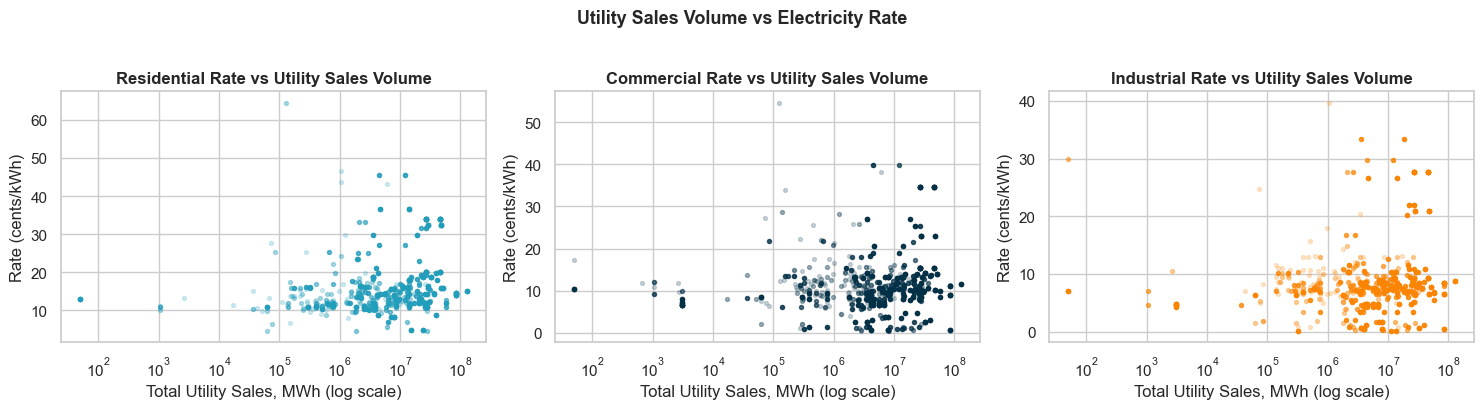

In [33]:
sample = df.sample(min(8000, len(df)), random_state=42).copy()
sample['total_sales_mwh'] = sample[sales_cols_detected].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    ax.scatter(s['total_sales_mwh'], s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
    ax.set_xscale('log')
    ax.set_xlabel('Total Utility Sales, MWh (log scale)')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Utility Sales Volume', fontweight='bold')

plt.suptitle('Utility Sales Volume vs Electricity Rate', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


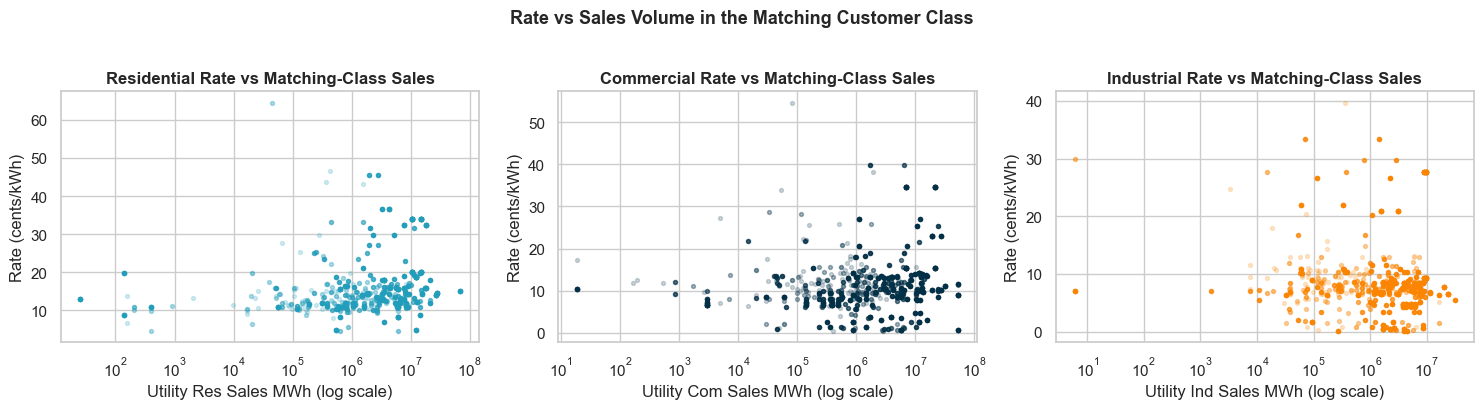

In [34]:
# Compare each rate type against sales volume in that *same* customer class
sales_by_type = {
    2: 'Utility Res Sales MWh',
    0: 'Utility Com Sales MWh',
    1: 'Utility Ind Sales MWh',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, ax in zip([2, 0, 1], axes):
    s = sample[sample['rate_type_index'] == idx]
    sales_col = sales_by_type[idx]
    ax.scatter(s[sales_col], s['rate'] * 100, alpha=0.2, s=8, color=colors[idx])
    ax.set_xscale('log')
    ax.set_xlabel(f'{sales_col} (log scale)')
    ax.set_ylabel('Rate (cents/kWh)')
    ax.set_title(f'{rate_labels[idx]} Rate vs Matching-Class Sales', fontweight='bold')

plt.suptitle('Rate vs Sales Volume in the Matching Customer Class', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
